     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 13.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Image 'bus.jpg' not found. Downloading a sample image...
Downloaded 'bus.jpg' to /content/bus.jpg

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 44.7ms
Speed: 11.8ms preprocess, 44.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)


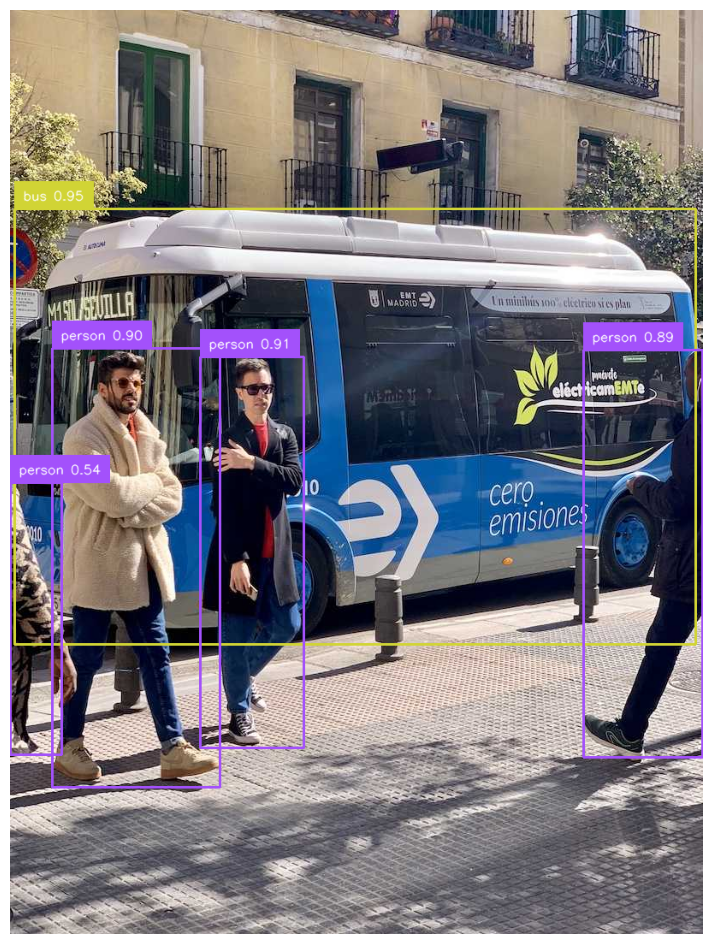

In [1]:
# Install required libraries if not already present
%pip install supervision ultralytics

import cv2
import supervision as sv
from ultralytics import YOLO # Corrected import statement
import os # Import os module

# 1. Load the pre-trained model (Nano version for speed)
model = YOLO('yolov10n.pt')

# 2. Path to your image (Replace with your file path if needed)
IMAGE_FILENAME = "bus.jpg"
IMAGE_PATH = os.path.join("/content", IMAGE_FILENAME) # Place in /content directory

# Check if the image file exists. If not, download it.
if not os.path.exists(IMAGE_PATH):
    print(f"Image '{IMAGE_FILENAME}' not found. Downloading a sample image...")
    # Use wget to download a sample image (e.g., from Ultralytics' GitHub assets)
    !wget -q https://ultralytics.com/images/bus.jpg -O {IMAGE_PATH}
    print(f"Downloaded '{IMAGE_FILENAME}' to {IMAGE_PATH}")
else:
    print(f"Using existing image at {IMAGE_PATH}")

# 3. Run Inference
results = model(IMAGE_PATH)[0]
detections = sv.Detections.from_ultralytics(results)

# 4. Create Visuals (Bounding Boxes + Labels)
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

# Generate labels based on detected classes
labels = [
    f"{model.names[class_id]} {confidence:.2f}"
    for class_id, confidence in zip(detections.class_id, detections.confidence)
]

# Apply annotations to the image
image = cv2.imread(IMAGE_PATH)
annotated_image = box_annotator.annotate(scene=image.copy(), detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections, labels=labels)

# 5. Display in Colab
%matplotlib inline
sv.plot_image(annotated_image)